In [4]:
# Density Estimation Explorer
**Lecture:** Part 01–03 — Inversion Sampling, Non-Parametric Density Estimation, Bias & Variance  
**Course:** Pattern Analysis — FAU Erlangen (Prof. Riess)

## What this notebook covers
1. **Part 01** — Generate samples from a custom distribution using Inversion Sampling
2. **Part 02** — Estimate the density back from those samples using Histograms, KDE (Parzen), and k-NN
3. **Part 03** — Visualize the Bias-Variance tradeoff by tuning the bandwidth `h` and `k`

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3187991646.py, line 2)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)
plt.rcParams["figure.dpi"] = 120

In [6]:
---
## Part 01 — Inversion Sampling
We define a custom PDF (a mixture of two Gaussians), compute its CDF numerically,
then use inversion sampling to draw random samples from it.

SyntaxError: invalid syntax (1137061298.py, line 1)

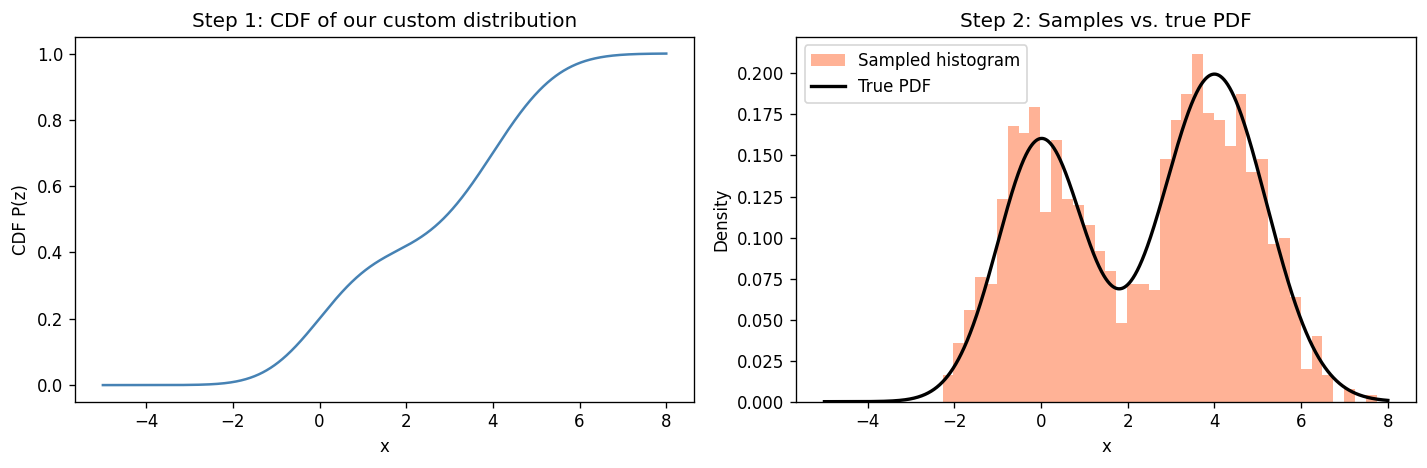

Generated 1000 samples via inversion sampling.


In [7]:
# Define a mixture-of-two-Gaussians PDF on a grid
x_grid = np.linspace(-5, 8, 2000)
pdf = 0.4 * np.exp(-0.5 * ((x_grid - 0) / 1.0)**2) / (1.0 * np.sqrt(2 * np.pi)) + \
      0.6 * np.exp(-0.5 * ((x_grid - 4) / 1.2)**2) / (1.2 * np.sqrt(2 * np.pi))
pdf /= np.trapz(pdf, x_grid)  # normalize to sum to 1

# Build the CDF numerically
cdf = np.cumsum(pdf) * (x_grid[1] - x_grid[0])
cdf /= cdf[-1]  # make sure it ends at exactly 1.0

# Inversion sampling: draw uniform u, find where CDF crosses u
N = 1000
u = np.random.uniform(0, 1, N)
samples = np.interp(u, cdf, x_grid)  # this is the "inversion" step

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_grid, cdf, color="steelblue")
axes[0].set_title("Step 1: CDF of our custom distribution")
axes[0].set_xlabel("x"); axes[0].set_ylabel("CDF P(z)")

axes[1].hist(samples, bins=40, density=True, alpha=0.6, color="coral", label="Sampled histogram")
axes[1].plot(x_grid, pdf, "k-", linewidth=2, label="True PDF")
axes[1].set_title("Step 2: Samples vs. true PDF")
axes[1].set_xlabel("x"); axes[1].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Generated {N} samples via inversion sampling.")

In [8]:
---
## Part 02 — Non-Parametric Density Estimation
Using the 1000 samples we just generated, we now try to *reconstruct* the original PDF 
using three estimators: Histograms, Parzen (KDE), and k-NN.

SyntaxError: invalid syntax (3297252025.py, line 1)

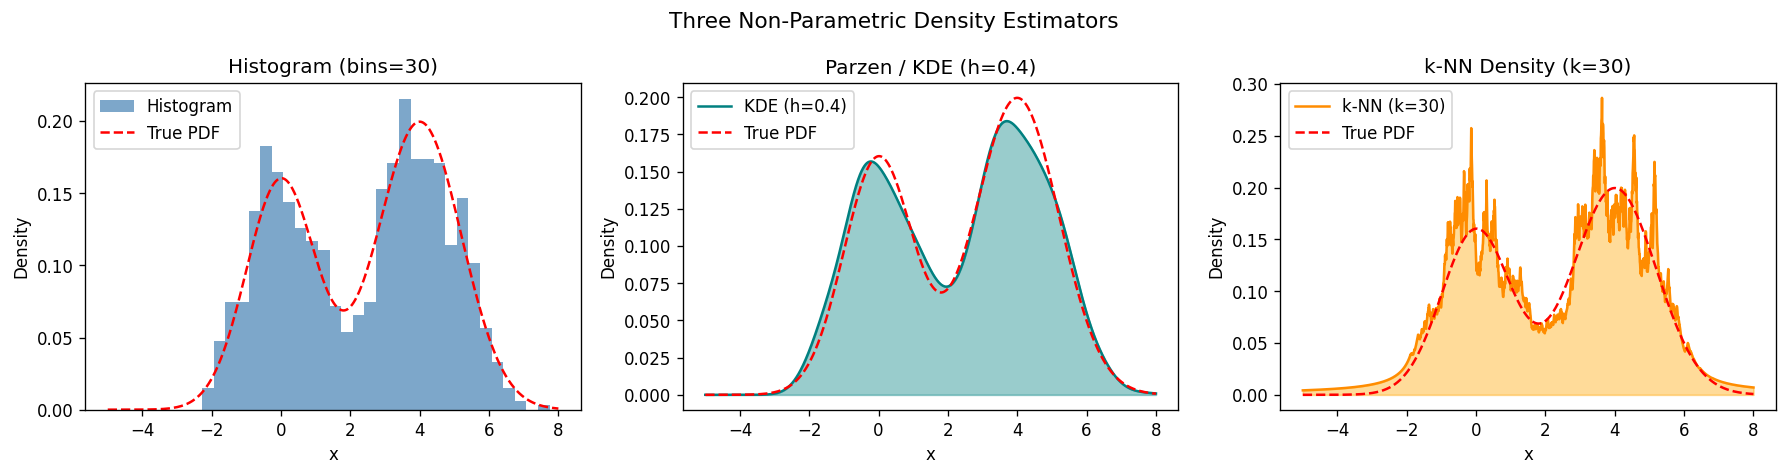

In [9]:
from sklearn.neighbors import KernelDensity

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram ---
axes[0].hist(samples, bins=30, density=True, color="steelblue", alpha=0.7, label="Histogram")
axes[0].plot(x_grid, pdf, "r--", linewidth=1.5, label="True PDF")
axes[0].set_title("Histogram (bins=30)")
axes[0].legend()

# --- KDE (Parzen / Gaussian kernel) ---
h = 0.4  # bandwidth
kde = KernelDensity(kernel="gaussian", bandwidth=h).fit(samples[:, None])
log_dens = kde.score_samples(x_grid[:, None])
axes[1].fill_between(x_grid, np.exp(log_dens), alpha=0.4, color="teal")
axes[1].plot(x_grid, np.exp(log_dens), color="teal", label=f"KDE (h={h})")
axes[1].plot(x_grid, pdf, "r--", linewidth=1.5, label="True PDF")
axes[1].set_title(f"Parzen / KDE (h={h})")
axes[1].legend()

# --- k-NN density ---
from sklearn.neighbors import NearestNeighbors
k = 30
nn = NearestNeighbors(n_neighbors=k).fit(samples[:, None])
knn_density = []
for xq in x_grid:
    dists, _ = nn.kneighbors([[xq]])
    V = 2 * dists[0, -1]  # 1D: volume = 2 * distance to k-th neighbor
    knn_density.append(k / (N * V))

axes[2].fill_between(x_grid, knn_density, alpha=0.4, color="orange")
axes[2].plot(x_grid, knn_density, color="darkorange", label=f"k-NN (k={k})")
axes[2].plot(x_grid, pdf, "r--", linewidth=1.5, label="True PDF")
axes[2].set_title(f"k-NN Density (k={k})")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("Density")

plt.suptitle("Three Non-Parametric Density Estimators", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
---
## Part 03 — Bias-Variance Tradeoff
What happens when we make the bandwidth `h` too small or too large?
- **Too small `h`** → spiky, noisy estimate → **high variance**
- **Too large `h`** → overly smooth, misses structure → **high bias**

SyntaxError: invalid character '→' (U+2192) (852599813.py, line 4)

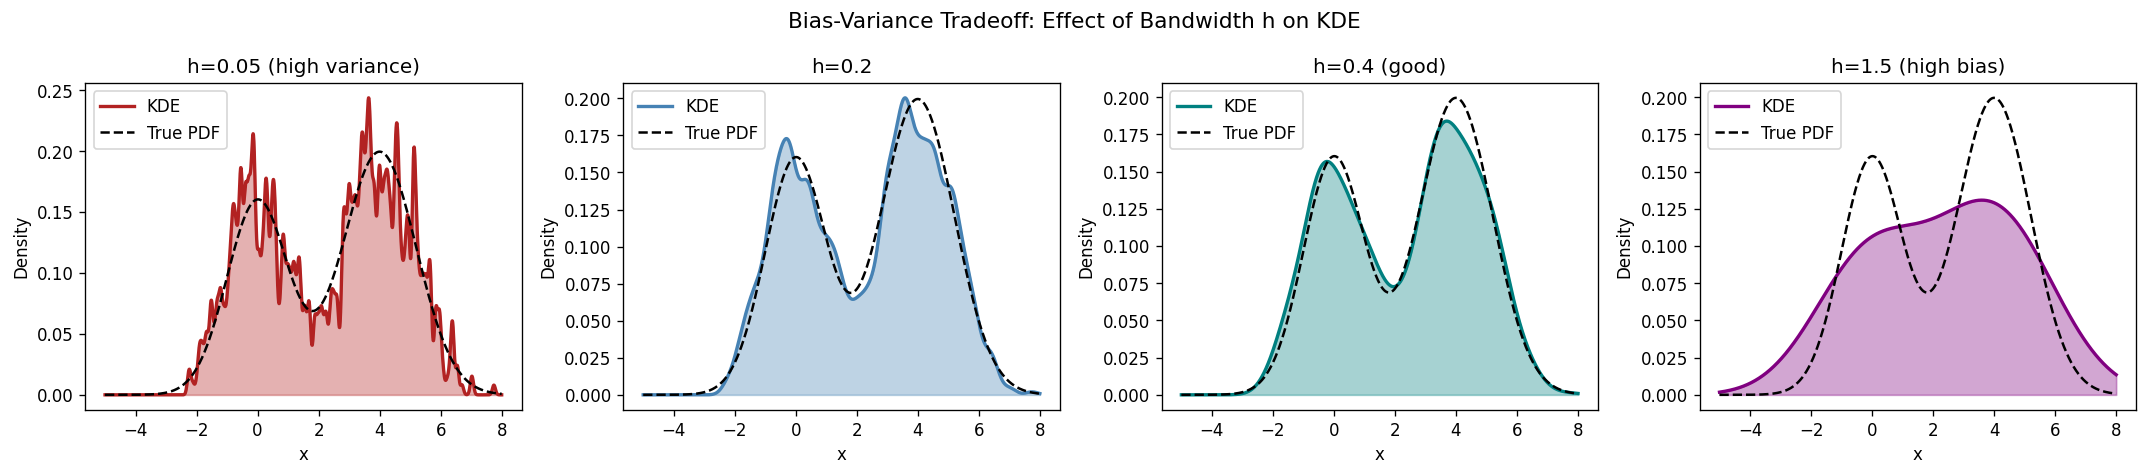

In [11]:
bandwidths = [0.05, 0.2, 0.4, 1.5]
labels = ["h=0.05 (high variance)", "h=0.2", "h=0.4 (good)", "h=1.5 (high bias)"]
colors = ["firebrick", "steelblue", "teal", "purple"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, h, label, color in zip(axes, bandwidths, labels, colors):
    kde = KernelDensity(kernel="gaussian", bandwidth=h).fit(samples[:, None])
    est = np.exp(kde.score_samples(x_grid[:, None]))
    ax.fill_between(x_grid, est, alpha=0.35, color=color)
    ax.plot(x_grid, est, color=color, linewidth=2, label=f"KDE")
    ax.plot(x_grid, pdf, "k--", linewidth=1.5, label="True PDF")
    ax.set_title(label)
    ax.set_xlabel("x"); ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Bias-Variance Tradeoff: Effect of Bandwidth h on KDE", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
---
## Takeaways

| Concept | What I learned |
|---|---|
| **Inversion Sampling** | Any distribution can be sampled by inverting its CDF. Works well when the CDF is known or can be computed numerically. |
| **Histogram** | Simple baseline, but sensitive to bin count. Discontinuous at bin edges. |
| **KDE (Parzen)** | Smooth, local density estimate. Bandwidth `h` is the key hyperparameter. |
| **k-NN Density** | Fixes number of neighbors `k`; volume varies. Adapts to data density automatically. |
| **Bias-Variance** | Small `h` → spiky (high variance). Large `h` → flat (high bias). Optimal `h` is found via cross-validation on held-out data. |

SyntaxError: invalid character '→' (U+2192) (2966849207.py, line 10)